In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

df = pd.read_csv(url)

columns = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
    "fuel_efficiency_mpg"
]

df = df[columns]

df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


Dataset shape: (10000, 5)

Missing values:
engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Horsepower median:
254.0

Target skewness:
0.08080419601878173


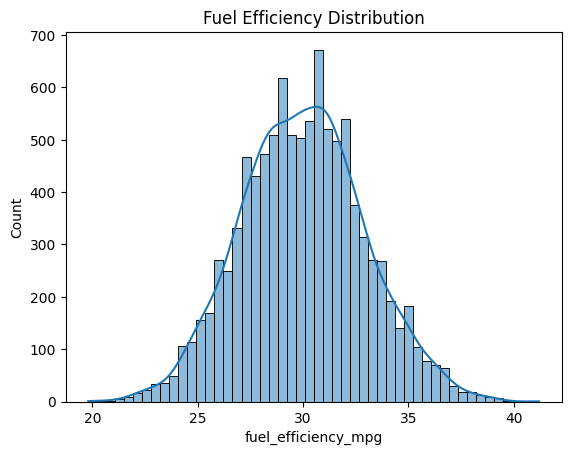

In [2]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())

print("\nHorsepower median:")
print(df["horsepower"].median())

print("\nTarget skewness:")
print(df["fuel_efficiency_mpg"].skew())

sns.histplot(df["fuel_efficiency_mpg"], bins=50, kde=True)
plt.title("Fuel Efficiency Distribution")
plt.show()

In [3]:
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year"
]

target = "fuel_efficiency_mpg"


def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    error = y - y_pred
    mse = (error ** 2).mean()
    return np.sqrt(mse)


# Train / validation / test split
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [4]:
y_train = df_train[target].values
y_val = df_val[target].values

# 1. Eksik değerleri 0 ile doldurma
X_train_zero = df_train[features].fillna(0).values
X_val_zero = df_val[features].fillna(0).values

w0, w = train_linear_regression(X_train_zero, y_train)
y_pred_zero = w0 + X_val_zero.dot(w)

rmse_zero = rmse(y_val, y_pred_zero)


# 2. Eksik değerleri training ortalamasıyla doldurma
horsepower_mean = df_train["horsepower"].mean()

X_train_mean = df_train[features].copy()
X_val_mean = df_val[features].copy()

X_train_mean["horsepower"] = X_train_mean["horsepower"].fillna(horsepower_mean)
X_val_mean["horsepower"] = X_val_mean["horsepower"].fillna(horsepower_mean)

X_train_mean = X_train_mean.values
X_val_mean = X_val_mean.values

w0, w = train_linear_regression(X_train_mean, y_train)
y_pred_mean = w0 + X_val_mean.dot(w)

rmse_mean = rmse(y_val, y_pred_mean)


print("RMSE with 0:", round(rmse_zero, 3))
print("RMSE with mean:", round(rmse_mean, 3))

RMSE with 0: 2.205
RMSE with mean: 2.202
